In [3]:
import sys
import os
import subprocess
from tqdm.auto import trange
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("/n/groups/marks/users/elain/PG2/ProteinGym/proteingym/baselines/EVmutation")

import score_mutants

import pandas as pd
import seaborn as sns

In [4]:
root = '/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2'

Testing:

In [ ]:
!/n/groups/marks/software/anaconda_o2/envs/proteingym_env/bin/python /n/groups/marks/users/elain/PG2/ProteinGym/proteingym/baselines/EVmutation/score_mutants.py \
--DMS_reference_file_path {root}/EVCouplings/output/Beltran_Lehner_2025/temp_ref_file.csv \
--DMS_data_folder {root}/DMS_assays/processed_data/Beltran_Lehner_2025 \
--model_folder {root}/EVCouplings/output/Beltran_Lehner_2025/selected_models --output_scores_folder {root}/EVmutation --DMS_index 0

Actual run

In [5]:
ref_file_df = pd.read_csv(root + '/EVCouplings/output/Beltran_Lehner_2025/temp_ref_file.csv')
total_index = len(ref_file_df)

In [6]:
for i in trange(total_index):
    cmd = [
        "/n/groups/marks/software/anaconda_o2/envs/proteingym_env/bin/python",
        "/n/groups/marks/users/elain/PG2/ProteinGym/proteingym/baselines/EVmutation/score_mutants.py",
        "--DMS_reference_file_path",
        f"{root}/EVCouplings/output/Beltran_Lehner_2025/temp_ref_file.csv",
        "--DMS_data_folder",
        f"{root}/DMS_assays/processed_data/Beltran_Lehner_2025",
        "--model_folder",
        f"{root}/EVCouplings/output/Beltran_Lehner_2025/selected_models",
        "--output_scores_folder",
        f"{root}/model_scores/EVmutation",
        "--DMS_index", f"{i}"
    ]
    print(ref_file_df.iloc[i]['DMS_id'])
    status = subprocess.run(cmd)
    if status.returncode != 0:
        break

  0%|          | 0/519 [00:00<?, ?it/s]

A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2
Offset: 1
FEZF1_HUMAN_Beltran_2025_PF00096_289
Offset: 288
SPD2B_HUMAN_Beltran_2025_PF00018_155
Offset: 154
SPD2B_HUMAN_Beltran_2025_PF00018_222
Offset: 221
A2RRE5_HUMAN_Beltran_2025_PF01846_267
Offset: 266
ASB14_HUMAN_Beltran_2025_PF07525_532
Offset: 531
WWP2_HUMAN_Beltran_2025_PF00397_440
Offset: 439
ODPX_HUMAN_Beltran_2025_PF02817_181
Offset: 180
CUX2_HUMAN_Beltran_2025_PF02376_1036
Offset: 1035
CUX2_HUMAN_Beltran_2025_PF02376_895
Offset: 894
DVL1_HUMAN_Beltran_2025_PF00595_246
Offset: 245
DVL1_HUMAN_Beltran_2025_PF00778_4
Offset: 3
TCRG1_HUMAN_Beltran_2025_PF01846_645
Offset: 644
TCRG1_HUMAN_Beltran_2025_PF01846_727
Offset: 726
TCRG1_HUMAN_Beltran_2025_PF01846_793
Offset: 792
TCRG1_HUMAN_Beltran_2025_PF01846_897
Offset: 896
TCRG1_HUMAN_Beltran_2025_PF01846_955
Offset: 954
PHX2A_HUMAN_Beltran_2025_PF00046_92
Offset: 91
KLF11_HUMAN_Beltran_2025_PF00096_395
Offset: 394
CSKP_HUMAN_Beltran_2025_PF00595_488
Offset: 487
MDM4_HUMAN_Beltran_2025_PF006

In [9]:
example_output = pd.read_csv(root + "/EVmutation/A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv")
res = spearmanr(example_output['normalized_fitness'], example_output['prediction_epistatic'])
res.statistic

0.15211780958799104

In [11]:
site_independent_spearman = []
evmutation_spearman = []
dms_id_list = []
for i, row in ref_file_df.iterrows():
    df = pd.read_csv(root + f"/EVmutation/{row['DMS_id']}.csv")
    dms_id_list.append(row['DMS_id'])
    site_independent_spearman.append(spearmanr(df['normalized_fitness'], df['prediction_independent']).statistic)
    evmutation_spearman.append(spearmanr(df['normalized_fitness'], df['prediction_epistatic']).statistic)

performance_df = pd.DataFrame({'DMS_id': dms_id_list,
                               'EVmutation_spearman': evmutation_spearman,
                               'Site_independent_spearman': site_independent_spearman})

In [13]:
performance_df.to_csv(root + '/EVCouplings/output/Beltran_Lehner_2025/evcouplings_scores.csv')

## Start here after calculating the evcouplings scores

In [11]:
performance_df = pd.read_csv(root + '/EVCouplings/output/Beltran_Lehner_2025/evcouplings_scores.csv')
ref_file_df = pd.read_csv(root + '/EVCouplings/output/Beltran_Lehner_2025/temp_ref_file.csv')
performance_df

,Unnamed: 0,DMS_id,EVmutation_spearman,Site_independent_spearman
0,0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.152118,0.240228
1,1,FEZF1_HUMAN_Beltran_2025_PF00096_289,0.245017,0.251281
2,2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.531846,0.478752
3,3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.422419,0.400016
4,4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.561854,0.550421
...,...,...,...,...
496,496,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.399946,0.355775
497,497,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.426051,0.356257
498,498,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.362053,0.355775
499,499,USH1C_HUMAN_Beltran_2025_PF00595_207,0.555840,0.474419


In [12]:
plot_df = ref_file_df.merge(performance_df, left_on='DMS_id', right_on='DMS_id')
plot_df

,DMS_id,MSA_bitscore,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_filename,EVCouplings_model_filename,target_seq,DMS_filename,offset,seq_len,Unnamed: 0,EVmutation_spearman,Site_independent_spearman
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.7,61559,0.971,68,5929.1,84.701140,medium,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.a2m,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.m...,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv,2,70,0,0.152118,0.240228
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,1.2,1740971,0.955,21,18757.1,852.595913,high,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.a2m,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.model,VCKVCGKGFRQASTLCRHKIIH,FEZF1_HUMAN_Beltran_2025_PF00096_289.csv,289,22,1,0.245017,0.251281
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.7,514768,0.891,49,14421.0,262.199550,high,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.model,EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...,SPD2B_HUMAN_Beltran_2025_PF00018_155.csv,155,55,2,0.531846,0.478752
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.7,503356,0.847,50,14439.4,244.735369,high,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.model,EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKE...,SPD2B_HUMAN_Beltran_2025_PF00018_222.csv,222,59,3,0.422419,0.400016
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.7,4543,0.952,60,128.7,2.042930,medium,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.a2m,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.model,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv,267,63,4,0.561854,0.550421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.9,275128,0.864,51,6534.3,110.750279,high,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.model,MVDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRR...,CD2AP_HUMAN_Beltran_2025_PF14604_1.csv,1,59,496,0.399946,0.355775
497,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.9,263728,0.869,53,6540.0,107.212910,high,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.model,KKRQCKVLFEYIPQNEDELELKVGDIIDINEEVEEGWWSGTLNNKL...,CD2AP_HUMAN_Beltran_2025_PF14604_109.csv,109,61,497,0.426051,0.356257
498,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.7,57518,0.828,48,1467.9,25.307762,medium,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.a2m,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.model,SRWTEEEMETAKKGLLEHGRNWSAIARMVGSKTVSQCKNFYFNYKK...,NCOR2_HUMAN_Beltran_2025_PF00249_613.csv,613,58,498,0.362053,0.355775
499,USH1C_HUMAN_Beltran_2025_PF00595_207,0.7,123337,0.831,74,1477.5,16.601235,medium,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.a2m,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.model,NKEKKVFISLVGSRGLGCSISSGPIQKPGIFISHVKPGSLSAEVGL...,USH1C_HUMAN_Beltran_2025_PF00595_207.csv,207,89,499,0.555840,0.474419


In [21]:
plot_df['EVmutation_spearman'].mean()

0.430742630194359

In [22]:
plot_df['Site_independent_spearman'].mean()

0.43026467733785095

In [13]:
plot_df = plot_df.rename(columns={'EVmutation_spearman': 'Spearman_EVmutation', 'Site_independent_spearman': 'Spearman_SiteIndependent'})

Text(0.5, 1.0, 'EVmutation')

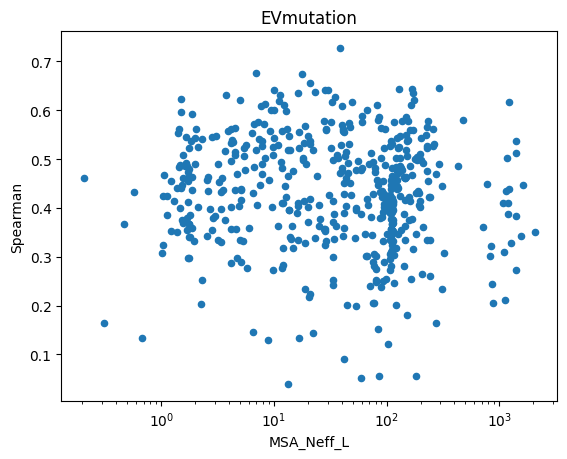

In [14]:
plot_df.plot.scatter(x='MSA_Neff_L', y='Spearman_EVmutation', c='C0')
plt.xscale('log')
plt.ylabel('Spearman')
plt.title('EVmutation')
# plt.savefig(root + '/EVCouplings/scripts/Beltran_Lehner_2025/EVmutation_spearman.pdf')

Text(0.5, 1.0, 'Site Independent')

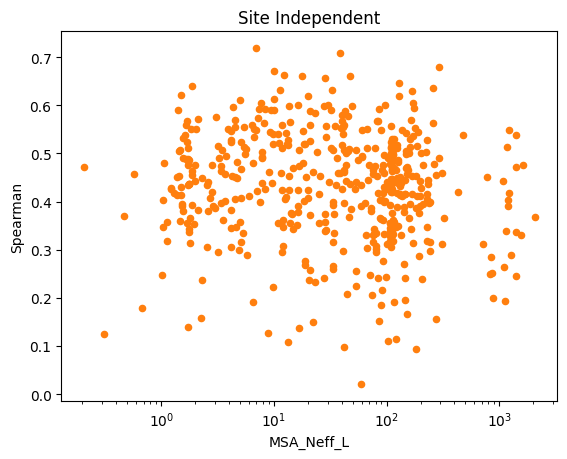

In [15]:
plot_df.plot.scatter(x='MSA_Neff_L', y='Spearman_SiteIndependent', c='C1')
plt.xscale('log')
plt.ylabel('Spearman')
plt.title('Site Independent')
# plt.savefig(root + '/EVCouplings/scripts/Beltran_Lehner_2025/SiteIndependent_spearman.pdf')

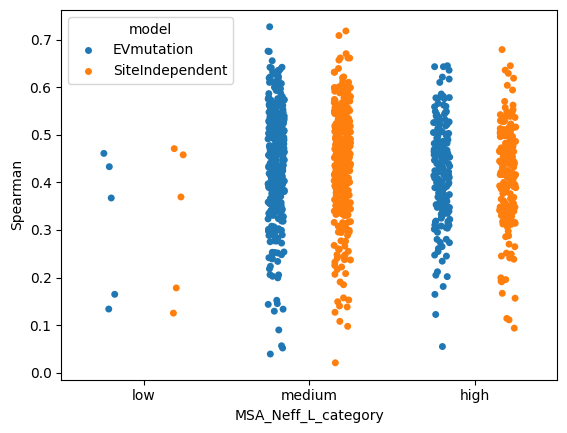

In [54]:
plot_df_long = pd.melt(plot_df, id_vars=['DMS_id', 'MSA_Neff_L_category'], value_vars=['Spearman_EVmutation', 'Spearman_SiteIndependent'])
plot_df_long = plot_df_long.rename(columns={"variable": "model"})
plot_df_long['model'] = plot_df_long['model'].replace({"Spearman_EVmutation": "EVmutation", "Spearman_SiteIndependent": "SiteIndependent"})
sns.stripplot(data=plot_df_long, x='MSA_Neff_L_category', y='value', hue='model', jitter=True, dodge=True, order=["low", "medium", "high"])
plt.ylabel('Spearman')
plt.savefig(root+'/EVCouplings/scripts/Beltran_Lehner_2025/spearman_neff_l.pdf')

In [16]:
plot_df['PFID'] = plot_df['DMS_id'].apply(lambda x: x.split('_')[4])
plot_df['uniprot'] = plot_df['DMS_id'].apply(lambda x: x.split('_')[0])
plot_df

,DMS_id,MSA_bitscore,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_filename,EVCouplings_model_filename,target_seq,DMS_filename,offset,seq_len,Unnamed: 0,Spearman_EVmutation,Spearman_SiteIndependent,PFID,uniprot
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.7,61559,0.971,68,5929.1,84.701140,medium,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.a2m,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.m...,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv,2,70,0,0.152118,0.240228,PF00240,A0A2R8Y422
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,1.2,1740971,0.955,21,18757.1,852.595913,high,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.a2m,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.model,VCKVCGKGFRQASTLCRHKIIH,FEZF1_HUMAN_Beltran_2025_PF00096_289.csv,289,22,1,0.245017,0.251281,PF00096,FEZF1
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.7,514768,0.891,49,14421.0,262.199550,high,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.model,EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...,SPD2B_HUMAN_Beltran_2025_PF00018_155.csv,155,55,2,0.531846,0.478752,PF00018,SPD2B
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.7,503356,0.847,50,14439.4,244.735369,high,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.model,EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKE...,SPD2B_HUMAN_Beltran_2025_PF00018_222.csv,222,59,3,0.422419,0.400016,PF00018,SPD2B
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.7,4543,0.952,60,128.7,2.042930,medium,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.a2m,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.model,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv,267,63,4,0.561854,0.550421,PF01846,A2RRE5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.9,275128,0.864,51,6534.3,110.750279,high,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.model,MVDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRR...,CD2AP_HUMAN_Beltran_2025_PF14604_1.csv,1,59,496,0.399946,0.355775,PF14604,CD2AP
497,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.9,263728,0.869,53,6540.0,107.212910,high,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.model,KKRQCKVLFEYIPQNEDELELKVGDIIDINEEVEEGWWSGTLNNKL...,CD2AP_HUMAN_Beltran_2025_PF14604_109.csv,109,61,497,0.426051,0.356257,PF14604,CD2AP
498,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.7,57518,0.828,48,1467.9,25.307762,medium,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.a2m,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.model,SRWTEEEMETAKKGLLEHGRNWSAIARMVGSKTVSQCKNFYFNYKK...,NCOR2_HUMAN_Beltran_2025_PF00249_613.csv,613,58,498,0.362053,0.355775,PF00249,NCOR2
499,USH1C_HUMAN_Beltran_2025_PF00595_207,0.7,123337,0.831,74,1477.5,16.601235,medium,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.a2m,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.model,NKEKKVFISLVGSRGLGCSISSGPIQKPGIFISHVKPGSLSAEVGL...,USH1C_HUMAN_Beltran_2025_PF00595_207.csv,207,89,499,0.555840,0.474419,PF00595,USH1C


In [17]:
plot_df['PFID'].value_counts()

PFID
PF00046    37
PF00018    36
PF00096    35
PF00595    31
PF00505    17
           ..
PF03671     1
PF01111     1
PF05741     1
PF05129     1
PF05715     1
Name: count, Length: 126, dtype: int64

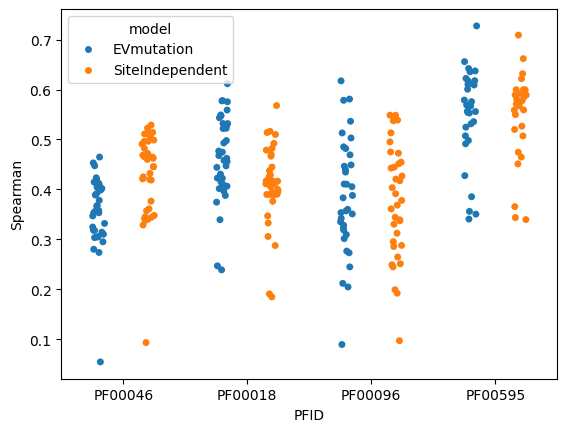

In [19]:
plot_df_long = pd.melt(plot_df[plot_df['PFID'].isin(['PF00046', 'PF00018', 'PF00096', 'PF00595'])], id_vars=['DMS_id', 'PFID'], value_vars=['Spearman_EVmutation', 'Spearman_SiteIndependent'])
plot_df_long = plot_df_long.rename(columns={"variable": "model"})
plot_df_long['model'] = plot_df_long['model'].replace({"Spearman_EVmutation": "EVmutation", "Spearman_SiteIndependent": "SiteIndependent"})
sns.stripplot(data=plot_df_long, x='PFID', y='value', hue='model', jitter=True, dodge=True, order=['PF00046', 'PF00018', 'PF00096', 'PF00595'])
plt.ylabel('Spearman')
plt.savefig(root+'/EVCouplings/scripts/Beltran_Lehner_2025/spearman_neff_l_top4_domains.pdf')

Despite overall similar performance between two models, we observe different performance in 3 out of top 4 most common domains assayed
- PF00046 is homeodomain
- PF00018 is SH3
- PF00096 is Zinc finger, C2H2 type
- PF00595 is PDZ domain

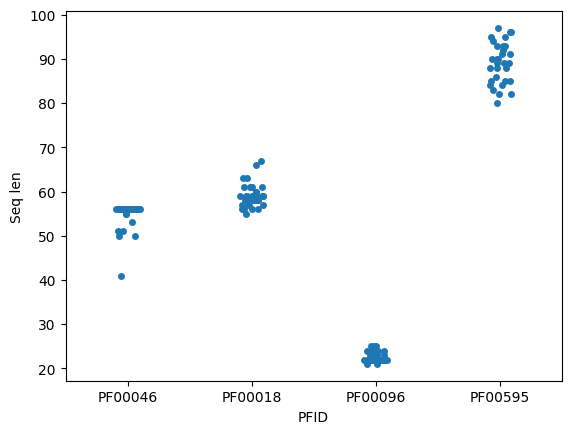

In [20]:
plot_df_long = pd.melt(plot_df[plot_df['PFID'].isin(['PF00046', 'PF00018', 'PF00096', 'PF00595'])], id_vars=['DMS_id', 'PFID'], value_vars=['seq_len'])
plot_df_long = plot_df_long.rename(columns={"variable": "Seq len"})
sns.stripplot(data=plot_df_long, x='PFID', y='value', jitter=True, dodge=True, order=['PF00046', 'PF00018', 'PF00096', 'PF00595'])
plt.ylabel('Seq len')
plt.savefig(root+'/EVCouplings/scripts/Beltran_Lehner_2025/seq_len_top4_domains.pdf')

In [50]:
plot_df

,DMS_id,MSA_bitscore,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_filename,EVCouplings_model_filename,target_seq,DMS_filename,offset,seq_len,Unnamed: 0,Spearman_EVmutation,Spearman_SiteIndependent,PFID,uniprot
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.7,61559,0.971,68,5929.1,84.701140,medium,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.a2m,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.m...,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv,2,70,0,0.152118,0.240228,PF00240,A0A2R8Y422
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,1.2,1740971,0.955,21,18757.1,852.595913,high,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.a2m,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.model,VCKVCGKGFRQASTLCRHKIIH,FEZF1_HUMAN_Beltran_2025_PF00096_289.csv,289,22,1,0.245017,0.251281,PF00096,FEZF1
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.7,514768,0.891,49,14421.0,262.199550,high,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.model,EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...,SPD2B_HUMAN_Beltran_2025_PF00018_155.csv,155,55,2,0.531846,0.478752,PF00018,SPD2B
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.7,503356,0.847,50,14439.4,244.735369,high,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.model,EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKE...,SPD2B_HUMAN_Beltran_2025_PF00018_222.csv,222,59,3,0.422419,0.400016,PF00018,SPD2B
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.7,4543,0.952,60,128.7,2.042930,medium,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.a2m,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.model,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv,267,63,4,0.561854,0.550421,PF01846,A2RRE5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.9,275128,0.864,51,6534.3,110.750279,high,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.model,MVDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRR...,CD2AP_HUMAN_Beltran_2025_PF14604_1.csv,1,59,496,0.399946,0.355775,PF14604,CD2AP
497,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.9,263728,0.869,53,6540.0,107.212910,high,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.model,KKRQCKVLFEYIPQNEDELELKVGDIIDINEEVEEGWWSGTLNNKL...,CD2AP_HUMAN_Beltran_2025_PF14604_109.csv,109,61,497,0.426051,0.356257,PF14604,CD2AP
498,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.7,57518,0.828,48,1467.9,25.307762,medium,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.a2m,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.model,SRWTEEEMETAKKGLLEHGRNWSAIARMVGSKTVSQCKNFYFNYKK...,NCOR2_HUMAN_Beltran_2025_PF00249_613.csv,613,58,498,0.362053,0.355775,PF00249,NCOR2
499,USH1C_HUMAN_Beltran_2025_PF00595_207,0.7,123337,0.831,74,1477.5,16.601235,medium,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.a2m,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.model,NKEKKVFISLVGSRGLGCSISSGPIQKPGIFISHVKPGSLSAEVGL...,USH1C_HUMAN_Beltran_2025_PF00595_207.csv,207,89,499,0.555840,0.474419,PF00595,USH1C


In [51]:
plot_df.to_csv('temp_ref_file_July7.csv')

<Axes: xlabel='seq_len', ylabel='Spearman_SiteIndependent'>

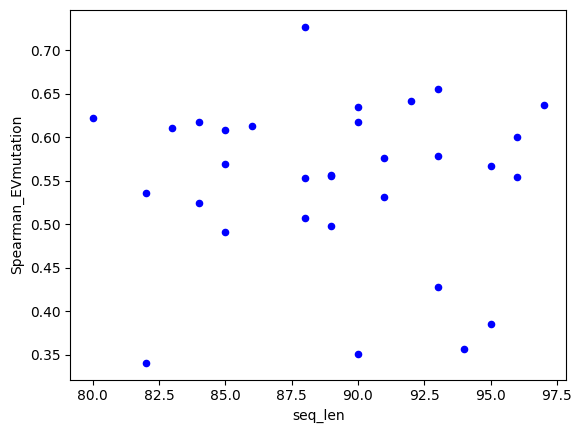

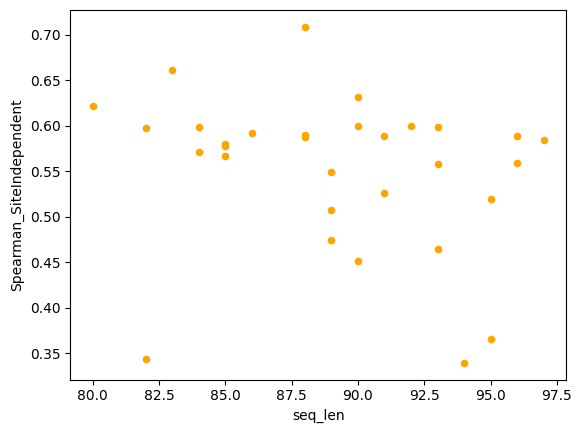

In [21]:
plot_df[plot_df['PFID'] == 'PF00595'].plot.scatter(x='seq_len', y='Spearman_EVmutation', color='blue')
plot_df[plot_df['PFID'] == 'PF00595'].plot.scatter(x='seq_len', y='Spearman_SiteIndependent', color='orange')

<Axes: xlabel='seq_len', ylabel='Spearman_SiteIndependent'>

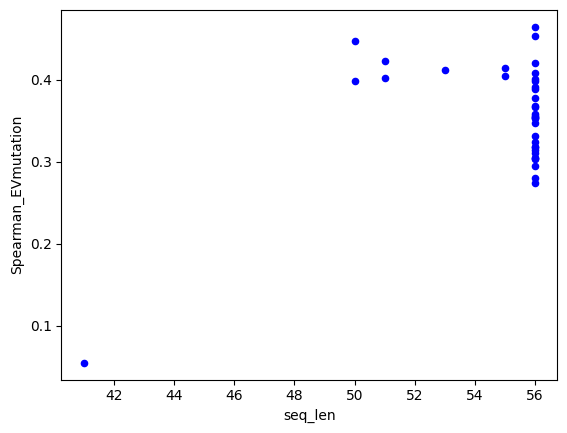

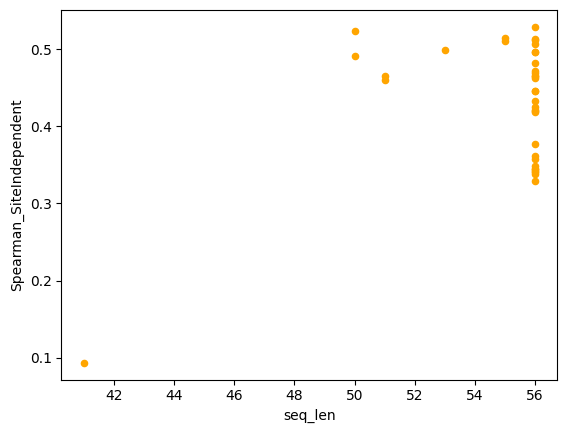

In [22]:
plot_df[plot_df['PFID'] == 'PF00046'].plot.scatter(x='seq_len', y='Spearman_EVmutation', color='blue')
plot_df[plot_df['PFID'] == 'PF00046'].plot.scatter(x='seq_len', y='Spearman_SiteIndependent', color='orange')

<Axes: xlabel='MSA_Neff_L', ylabel='Spearman_EVmutation'>

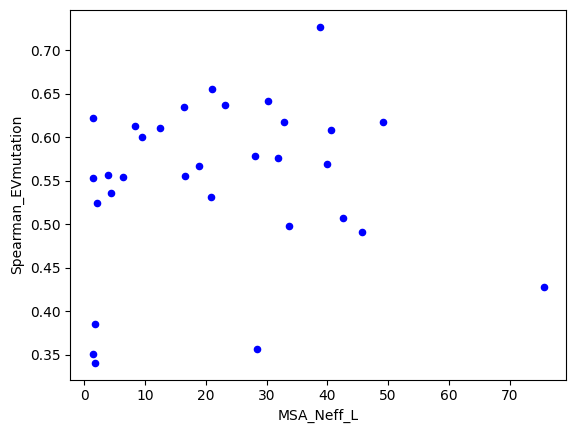

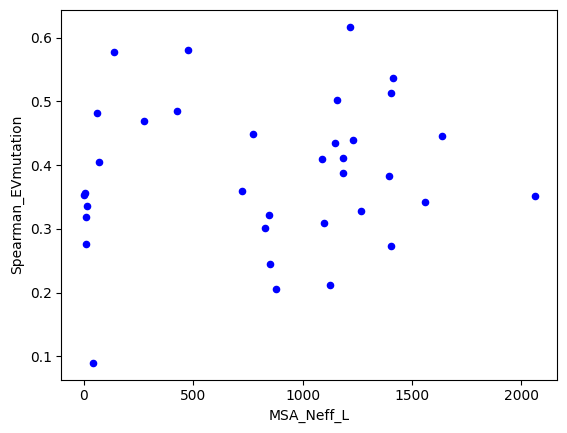

In [23]:
plot_df[plot_df['PFID'] == 'PF00595'].plot.scatter(x='MSA_Neff_L', y='Spearman_EVmutation', color='blue')
plot_df[plot_df['PFID'] == 'PF00096'].plot.scatter(x='MSA_Neff_L', y='Spearman_EVmutation', color='blue')

No clear correlation of Spearman with sequence length and Neff_L

### Check the same pairs of uniprotID-PFID vs MSA Neff/L

conclusion: unclear whether higher MSA Neff/L gives rise to higher spearman correlation

/n/groups/marks/software/anaconda_o2/envs/proteingym_env/lib/python3.9/site-packages/pandas/plotting/_matplotlib/tools.py:225: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(**fig_kw)


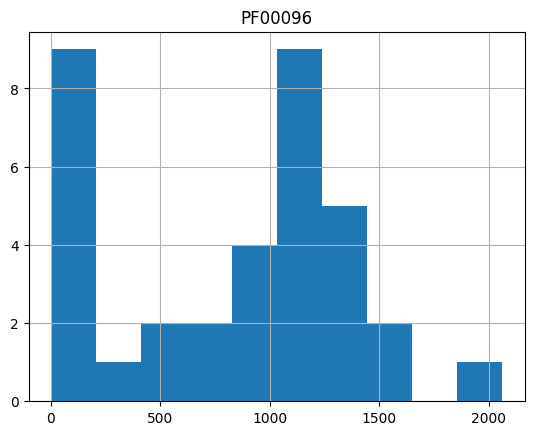

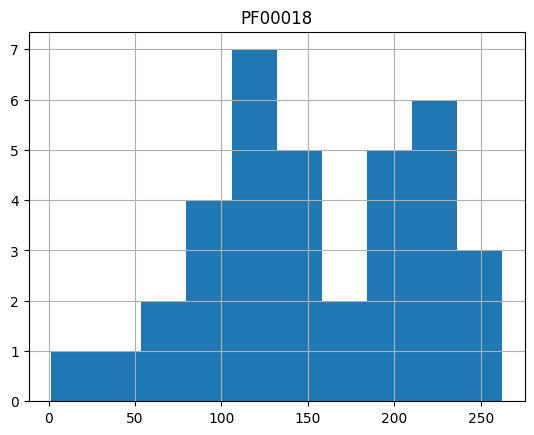

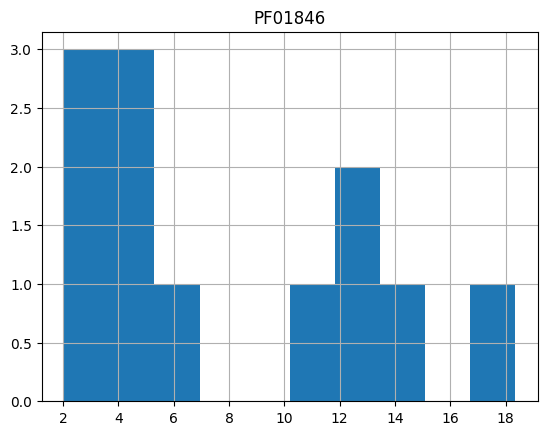

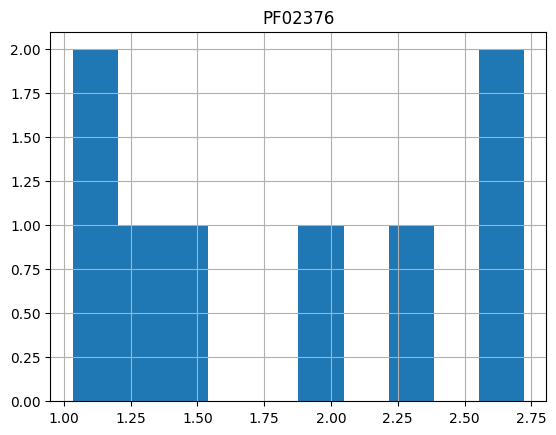

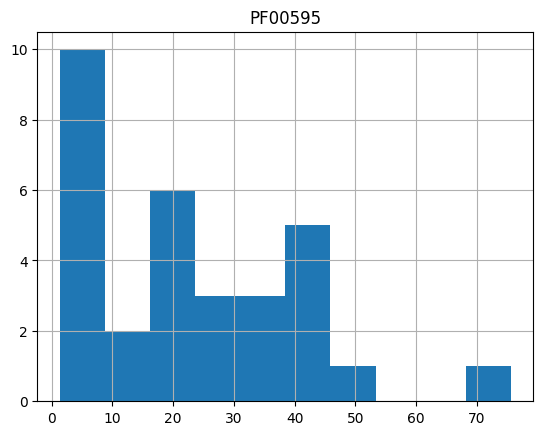

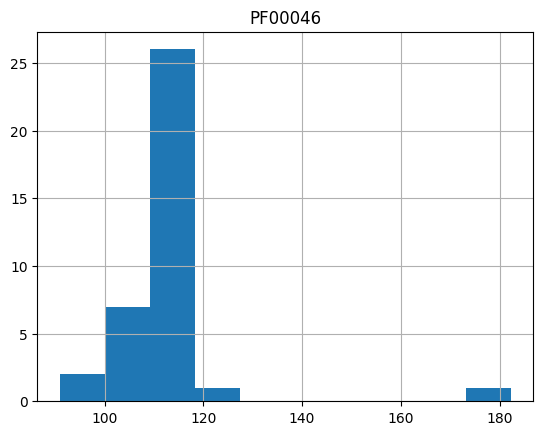

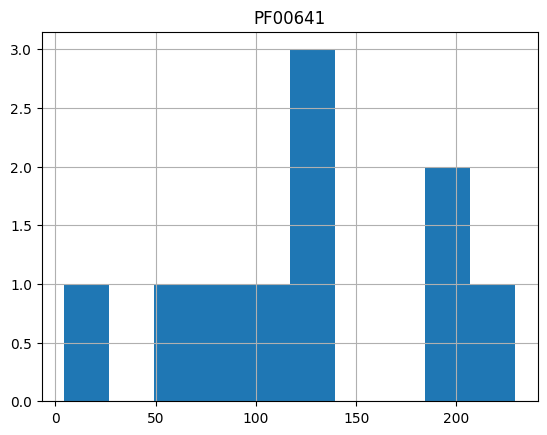

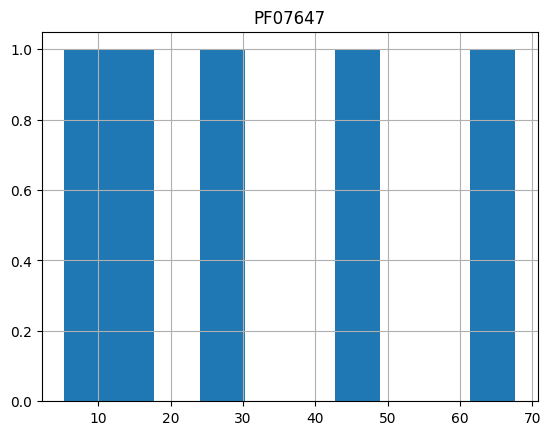

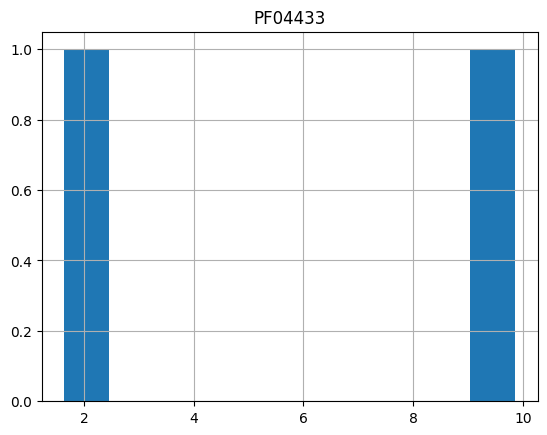

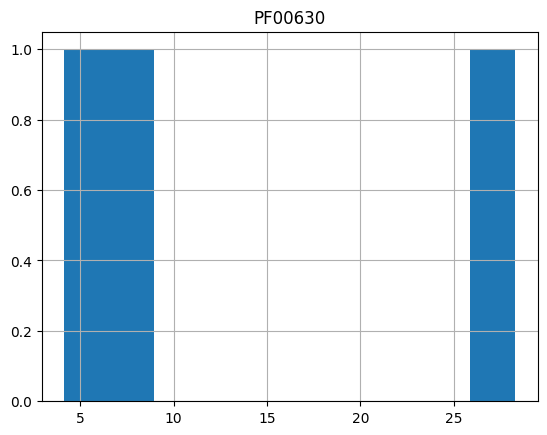

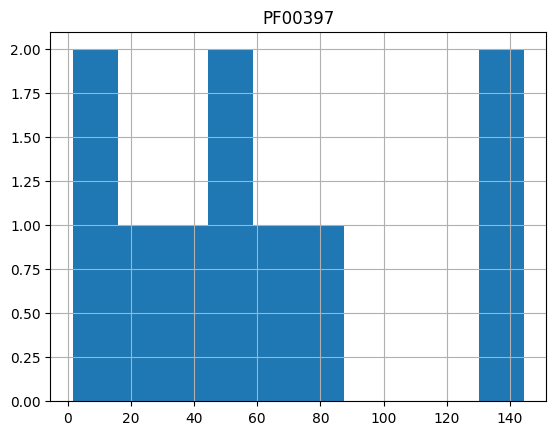

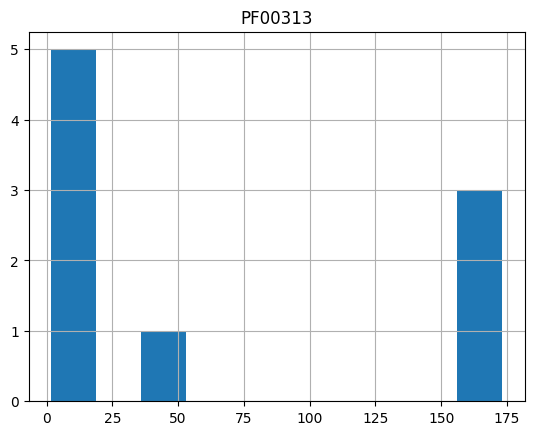

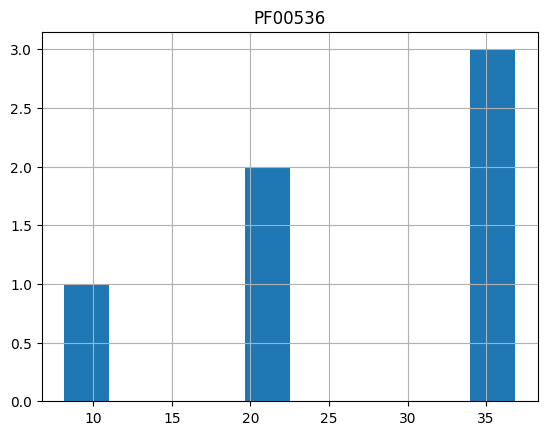

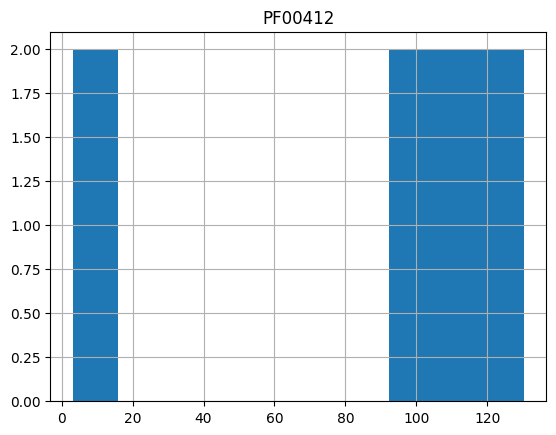

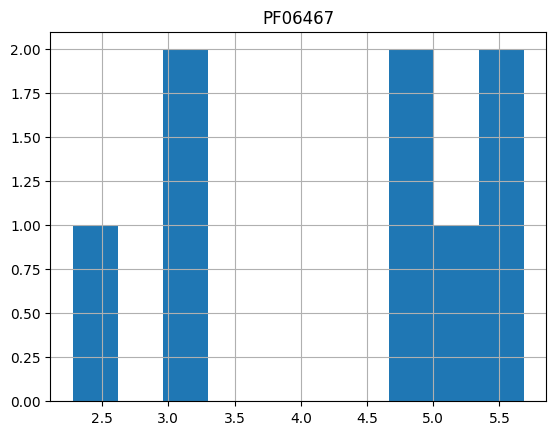

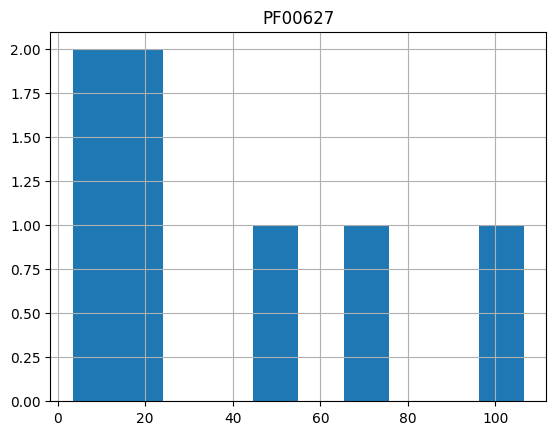

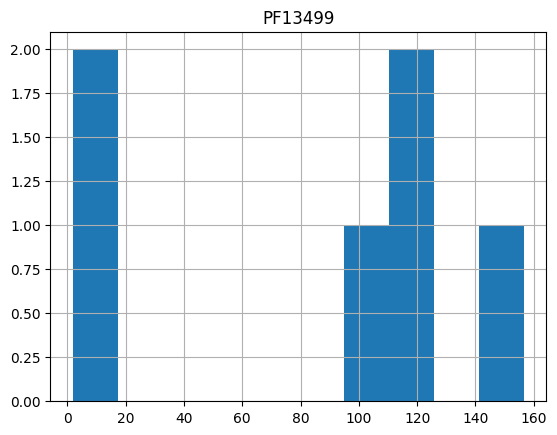

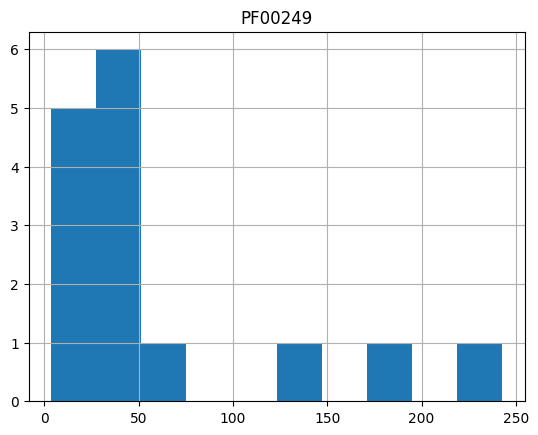

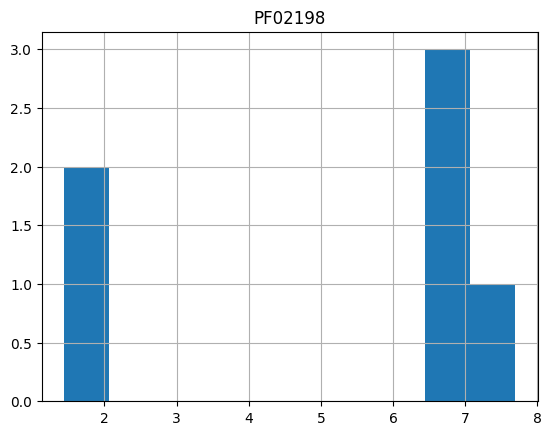

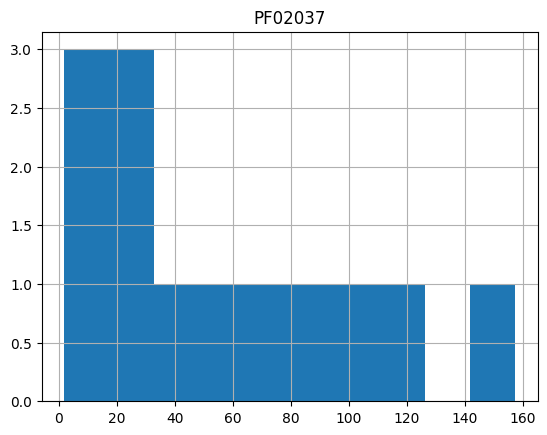

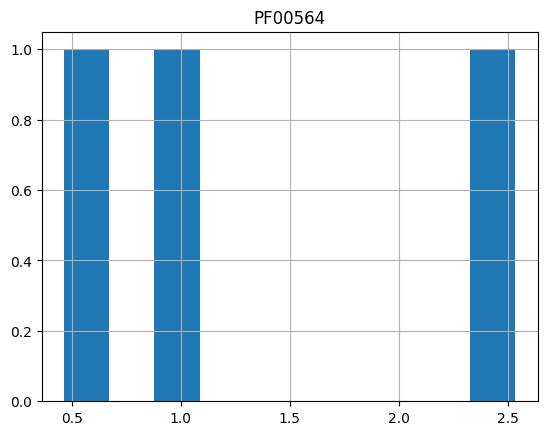

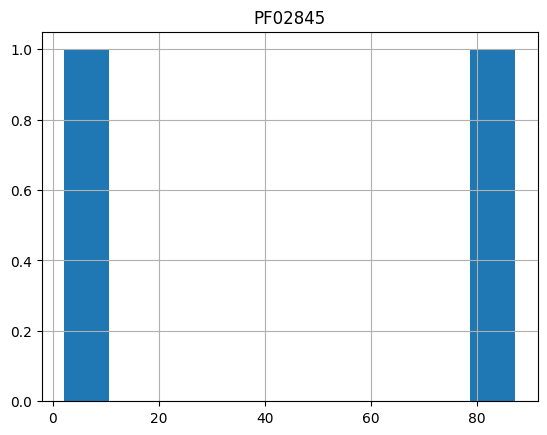

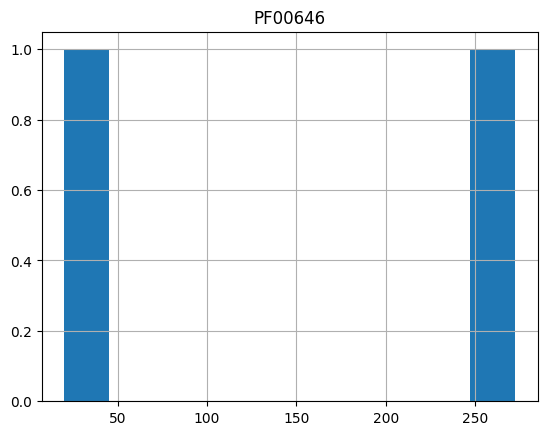

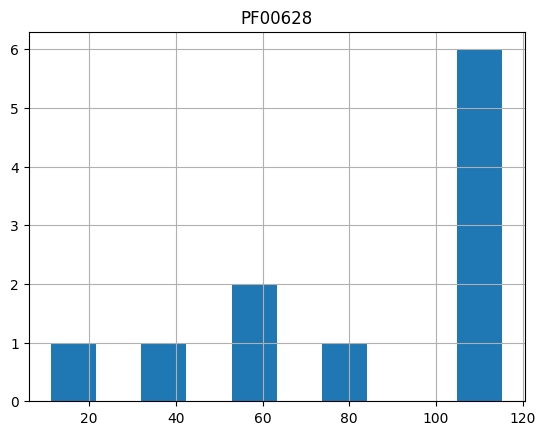

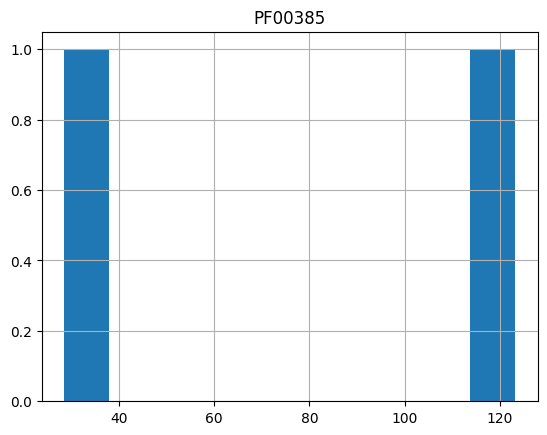

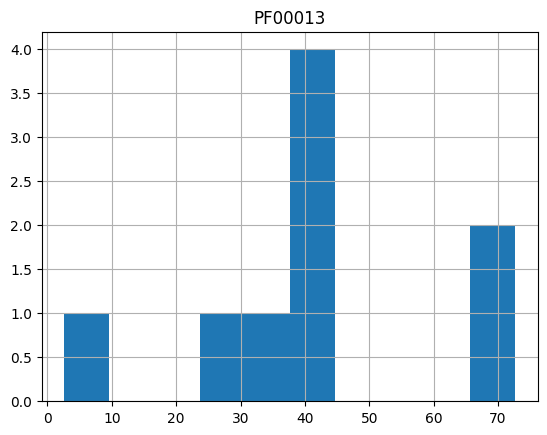

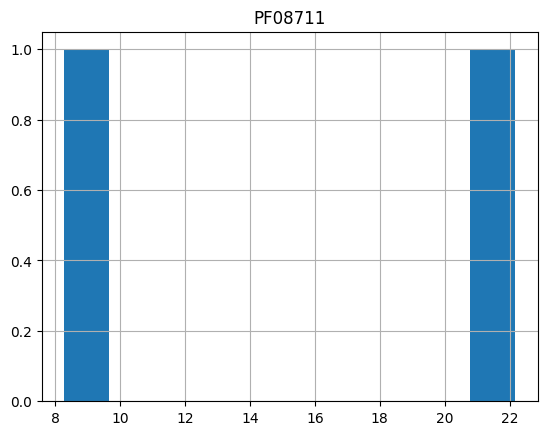

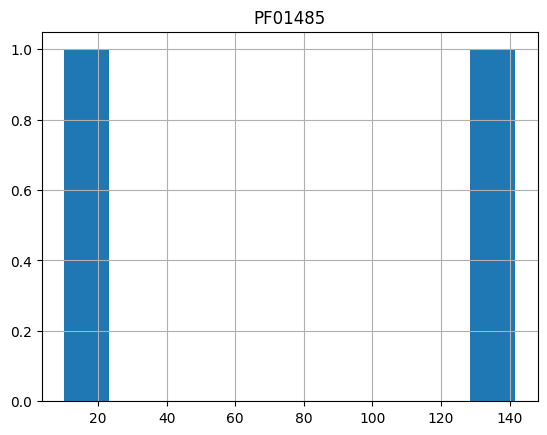

In [55]:
for PFID in plot_df['PFID'].unique():
    if (plot_df[plot_df['PFID'] == PFID]['MSA_Neff_L'].max()-plot_df[plot_df['PFID'] == PFID]['MSA_Neff_L'].min())/plot_df[plot_df['PFID'] == PFID]['MSA_Neff_L'].min() > 1:
        plot_df[plot_df['PFID'] == PFID].hist('MSA_Neff_L')
        plt.title(PFID)

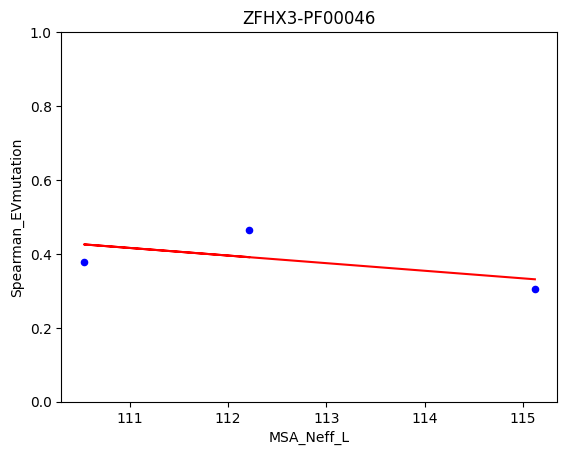

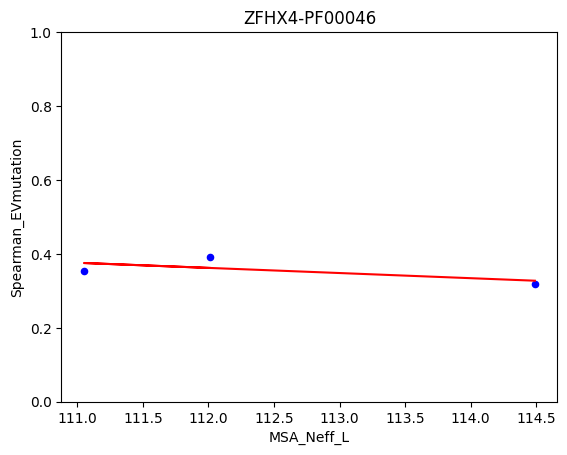

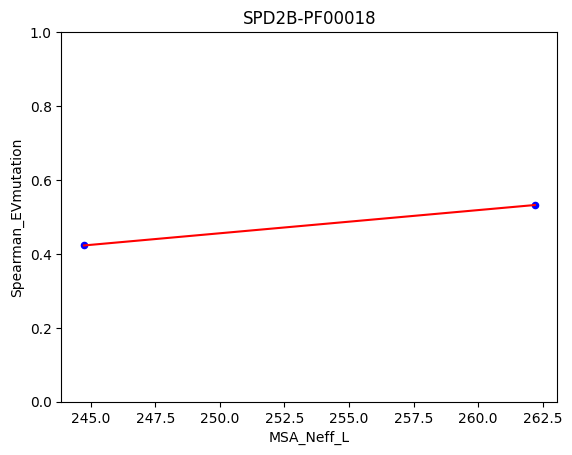

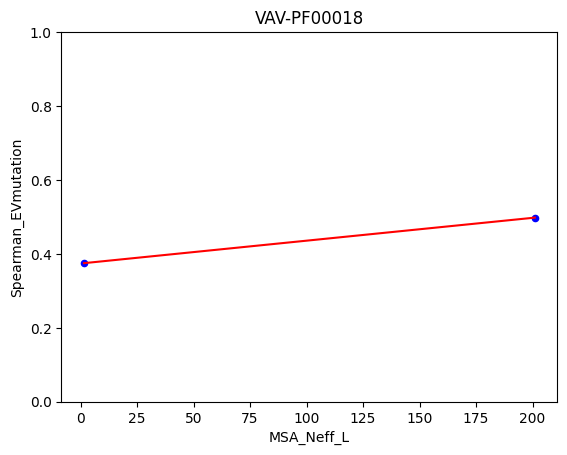

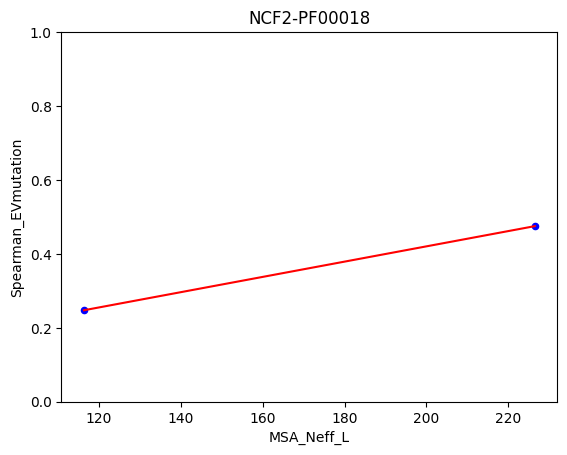

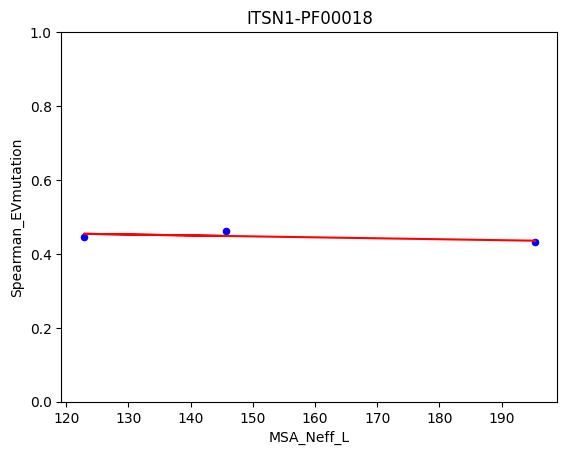

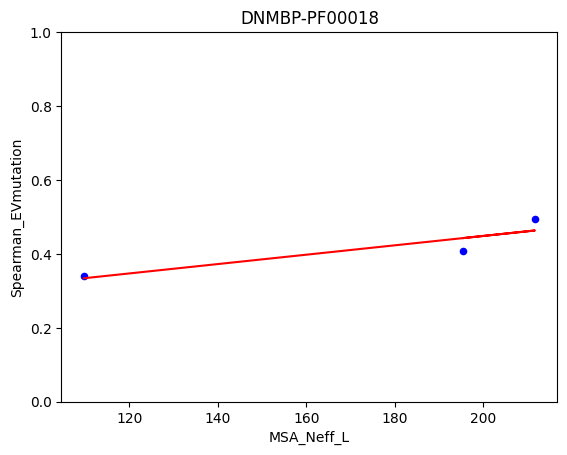

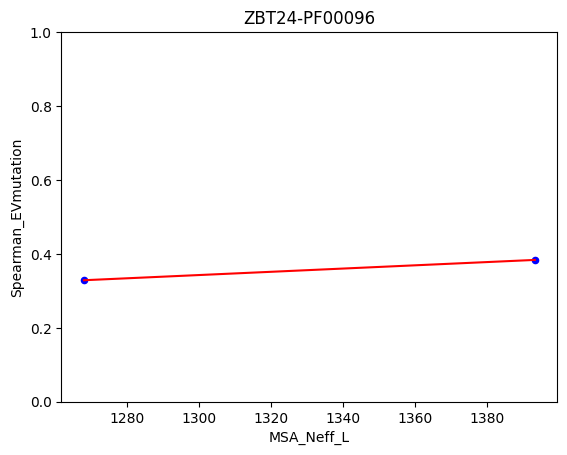

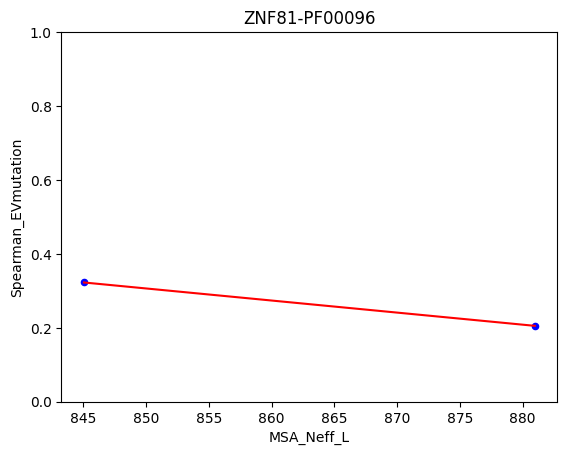

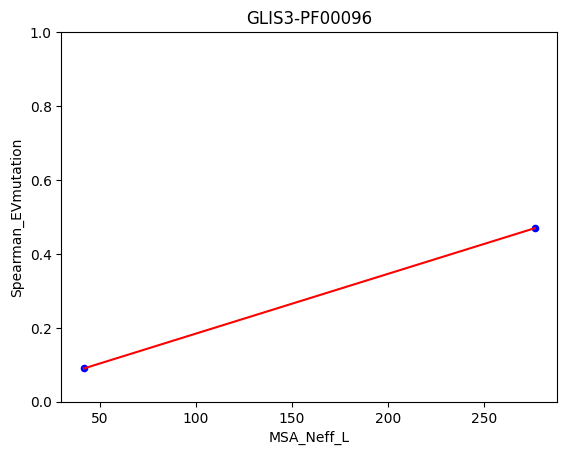

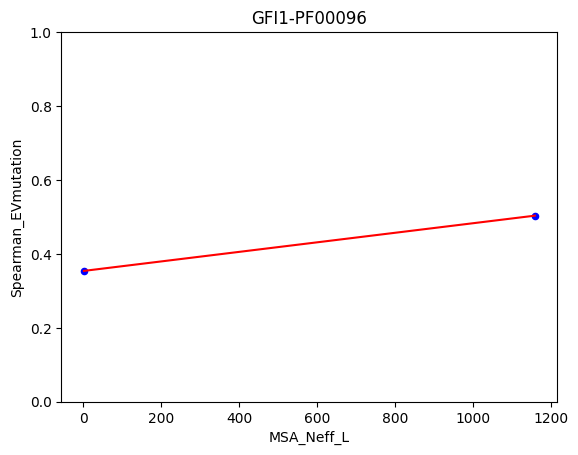

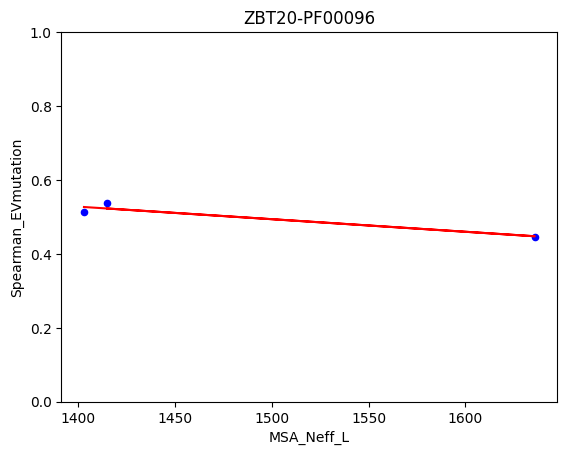

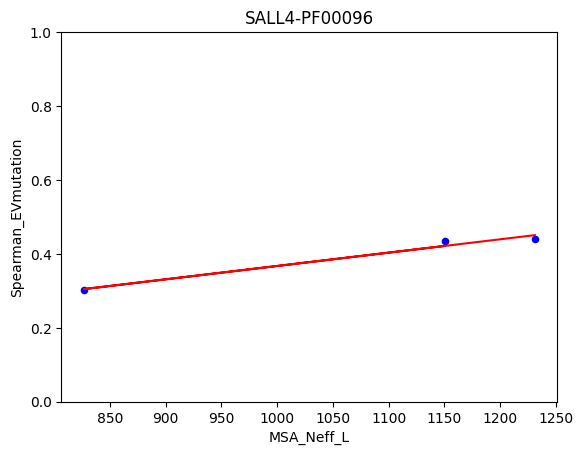

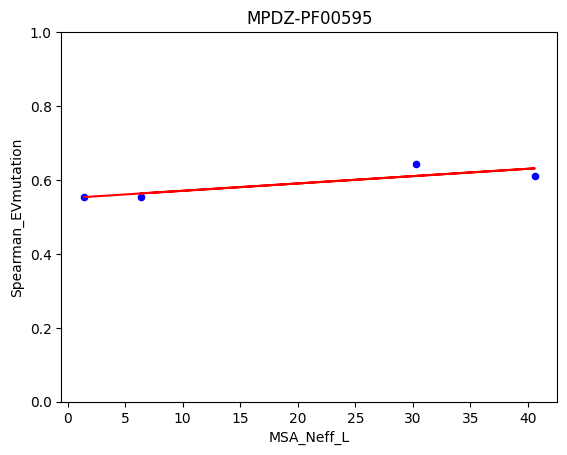

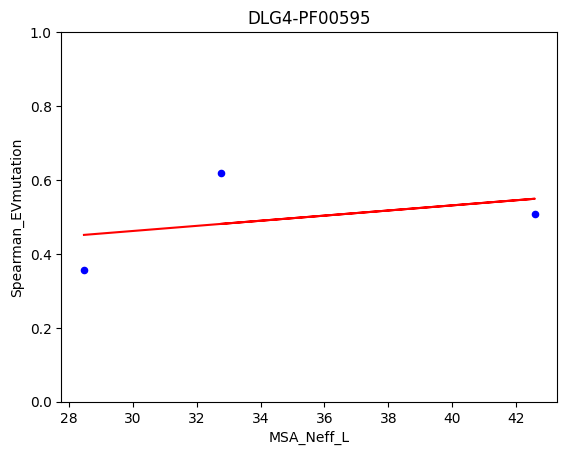

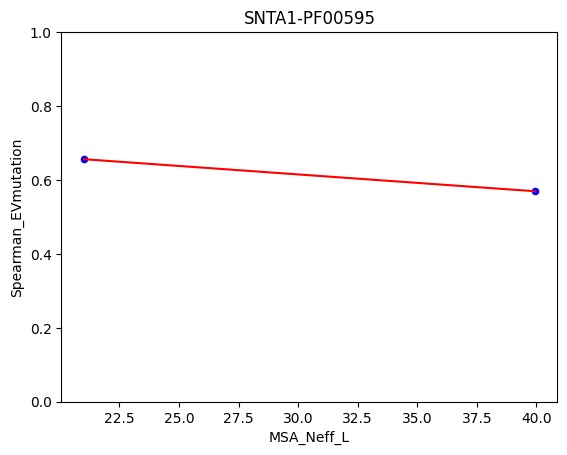

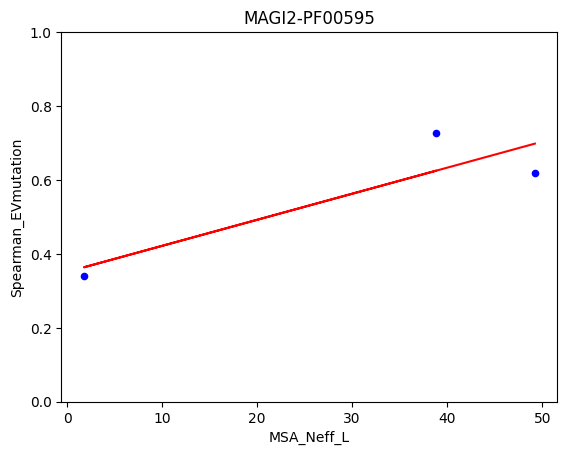

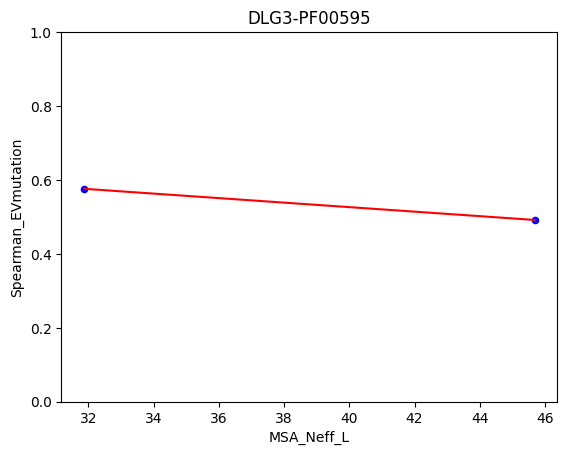

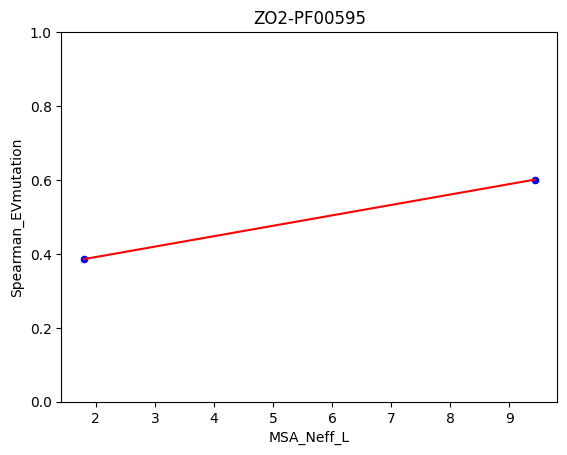

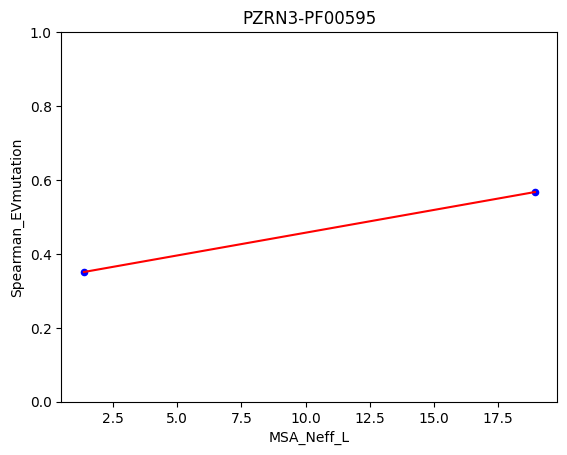

In [45]:
positive_slope = []
negative_slope = []
for PFID in ['PF00046', 'PF00018', 'PF00096', 'PF00595']:
    for uniprot in list(plot_df[plot_df['PFID'] == PFID]['uniprot'].unique()):
        df = plot_df[(plot_df['PFID'] == PFID) & (plot_df['uniprot'] == uniprot)]
        if len(df) > 1:
            sub_df = df[df['uniprot'] == uniprot]
            sub_df.plot.scatter(x='MSA_Neff_L', y='Spearman_EVmutation', color='blue')
            plt.title(uniprot + "-" + PFID)
            plt.ylim(0, 1)
            m, c = np.polyfit(sub_df['MSA_Neff_L'], sub_df['Spearman_EVmutation'], 1)
            if m > 0:
                positive_slope.append(uniprot + "-" + PFID)
            else:
                negative_slope.append(uniprot + "-" + PFID)
            line_y = m * sub_df['MSA_Neff_L'] + c
            plt.plot(sub_df['MSA_Neff_L'], line_y, color='red', label=f'Best-Fit Line: y = {m:.2f}x + {c:.2f}')
            # plt.legend()
            plt.show()

In [49]:
print("spearman increases with higher Neff_L:")
print(positive_slope)
print("spearman decreases with higher Neff_L:")
print(negative_slope)

spearman increases with higher Neff_L:
['SPD2B-PF00018', 'VAV-PF00018', 'NCF2-PF00018', 'DNMBP-PF00018', 'ZBT24-PF00096', 'GLIS3-PF00096', 'GFI1-PF00096', 'SALL4-PF00096', 'MPDZ-PF00595', 'DLG4-PF00595', 'MAGI2-PF00595', 'ZO2-PF00595', 'PZRN3-PF00595']
spearman decreases with higher Neff_L:
['ZFHX3-PF00046', 'ZFHX4-PF00046', 'ITSN1-PF00018', 'ZNF81-PF00096', 'ZBT20-PF00096', 'SNTA1-PF00595', 'DLG3-PF00595']


## Check why the alignments from the same PFID have very large Neff/L variations
1. Check the existing alignments - did we pick the wrong one for the same PFID in the same UniProtID?
2. Check the HMM profiles - do they look similar?

Use VAV_PF00018 as an example (UniProt ID is P15498)

In [6]:
round3_aln_stats = pd.read_csv(root + "/EVCouplings/output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_full_Jul8_aln_stats.csv")

In [7]:
round3_aln_stats[round3_aln_stats['protein'] == 'P15498_PF00018_782']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
118,P15498_PF00018_782,486472,486792,0.999343,12262.496327,201.024530,61,51,0.836066,0.7
119,P15498_PF00018_782,241991,242143,0.999372,5819.449679,95.400814,61,51,0.836066,0.9
120,P15498_PF00018_782,14095,14102,0.999504,333.555836,5.468128,61,55,0.901639,1.1


The other one "P15498_PF00018_592" has Neff/L 1.52. This is actually not too different from the above at bitscore = 1.1 (Neff/L=5.47). Should change the function to select the best MSA.

## Score on all a2m files, regardless of whether they are selected
1. Copy all the models to a directory

In [ ]:
!bash move_all_models.sh